In [79]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re
import math
from scipy.optimize import fsolve

In [80]:
df_raw = pd.read_csv("data/icecube_public.txt")

In [81]:
col_str = str(list(df_raw.columns)[0])
col_headers = col_str.split()[1:]
data_cols = ['MJD[days]','log10(E/GeV)','AngErr[deg]', 'RA[deg]', 'Dec[deg]']
df_stripped = df_raw[col_str].str.strip()
is_numeric = df_stripped.str.match(r"\d+")
df_string = df_stripped[is_numeric]

In [82]:
df = pd.DataFrame()
df[col_headers] = df_string.str.split("\s+", expand=True)
df = df.astype(float)

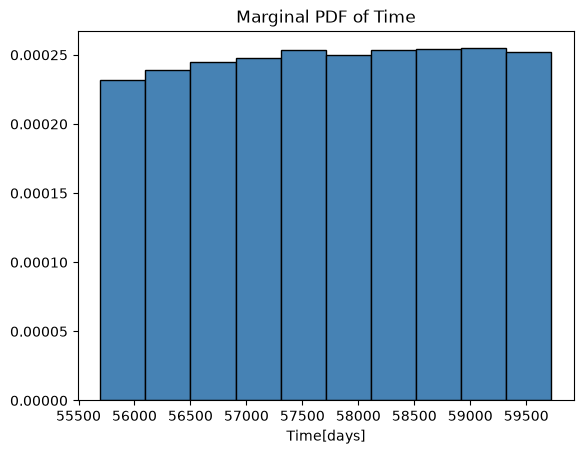

In [83]:
plt.hist(df["MJD[days]"], density=True,edgecolor = "black", color="steelblue")
plt.xlabel("Time[days]")
plt.title("Marginal PDF of Time")
plt.show()

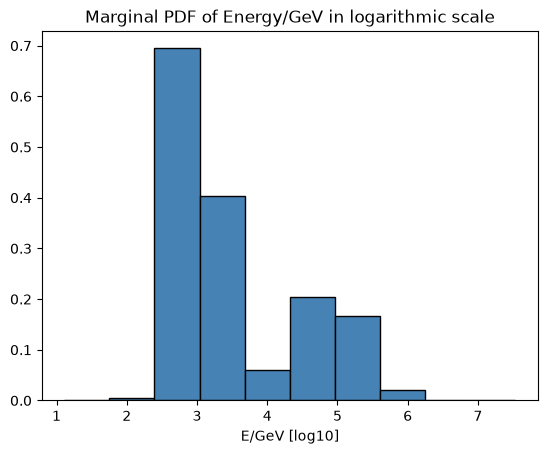

In [84]:
plt.hist(df["log10(E/GeV)"], density=True,color="steelblue",edgecolor = "black")
plt.xlabel("E/GeV [log10]")
plt.title("Marginal PDF of Energy/GeV in logarithmic scale")
plt.show()

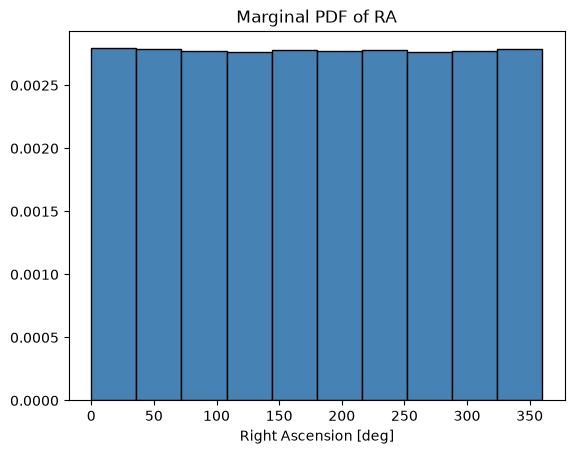

In [85]:
plt.hist(df["RA[deg]"], density=True,color="steelblue",edgecolor = "black")
plt.xlabel("Right Ascension [deg]")
plt.title("Marginal PDF of RA")
plt.show()

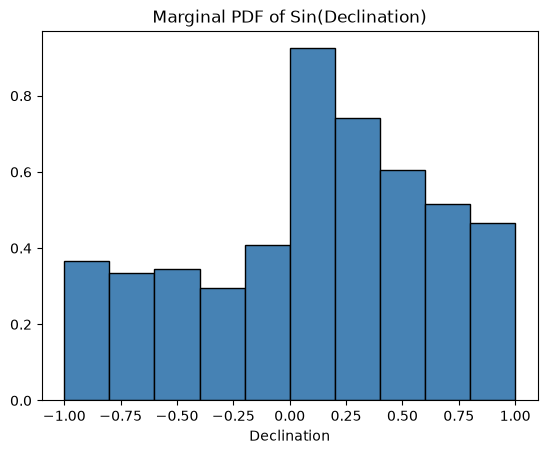

In [86]:
plt.hist(np.sin(df["Dec[deg]"]*np.pi/180), density=True,color="steelblue",edgecolor = "black")
plt.xlabel("Declination")
plt.title("Marginal PDF of Sin(Declination)")
plt.show()

We care about sin(declination) instead of declination because it represents a physical ratio of how much sky we see and in what direction relative to the radius of the earth.

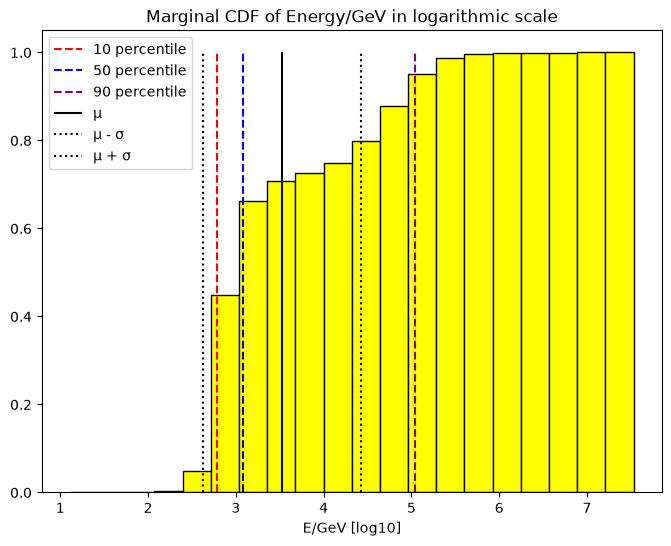

In [87]:
plt.figure(figsize=(8, 6))
for i,c in zip([10,50,90],["red","blue","purple"]):
    plt.vlines(np.percentile(df["log10(E/GeV)"],i), 
               ymin=0, ymax=1, colors=c, linestyle="dashed", label=f"{i} percentile")

plt.vlines(np.mean(df["log10(E/GeV)"]), ymin=0, ymax=1, colors= "black", linestyle="solid", label="\u03bc")
plt.vlines(np.mean(df["log10(E/GeV)"]) - np.std(df["log10(E/GeV)"]), ymin=0, ymax=1, colors= "black", linestyle=":", label="\u03bc - \u03C3")
plt.vlines(np.mean(df["log10(E/GeV)"]) + np.std(df["log10(E/GeV)"]), ymin=0, ymax=1, colors= "black", linestyle=":", label="\u03bc + \u03C3")

plt.hist(df["log10(E/GeV)"], bins=20, density=True, color="yellow" ,edgecolor = "black", cumulative=True)

plt.xlabel("E/GeV [log10]")
plt.title("Marginal CDF of Energy/GeV in logarithmic scale")
plt.legend()
plt.show()

In [88]:
time = np.array(df["MJD[days]"])*86400

In [89]:
time_diff = time[1:] - time[:-1]
time_diff_positive = time_diff[time_diff > 0]
time_diff_1000 = time_diff_positive[time_diff_positive <= 1000]

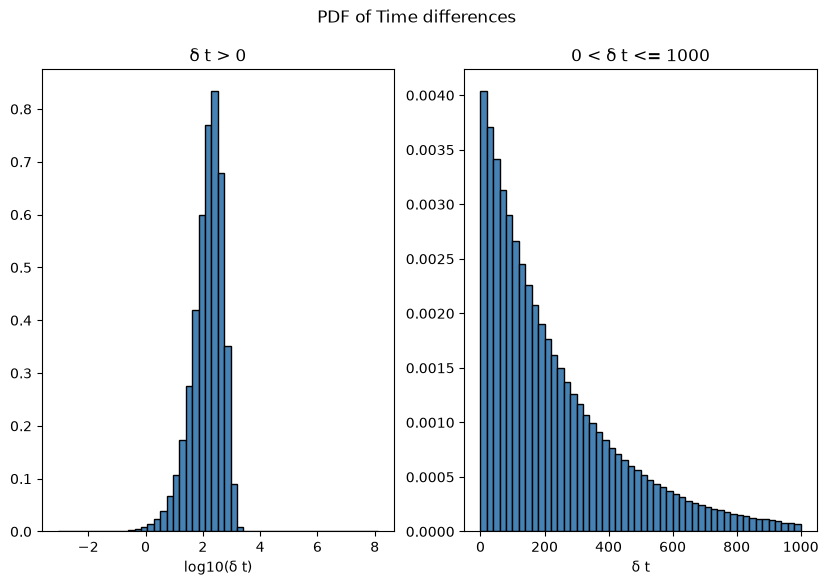

In [90]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10,6))
fig.suptitle('PDF of Time differences')
ax1.hist(np.log10(time_diff_positive), bins=50, edgecolor="black", color="steelblue", density=True)
ax2.hist(time_diff_1000, bins=50, edgecolor="black", color="steelblue", density=True)
ax1.set_title("\u03B4 t > 0")
ax2.set_title("0 < \u03B4 t <= 1000")
ax1.set_xlabel("log10(\u03B4 t)")
ax2.set_xlabel("\u03B4 t")
plt.show()

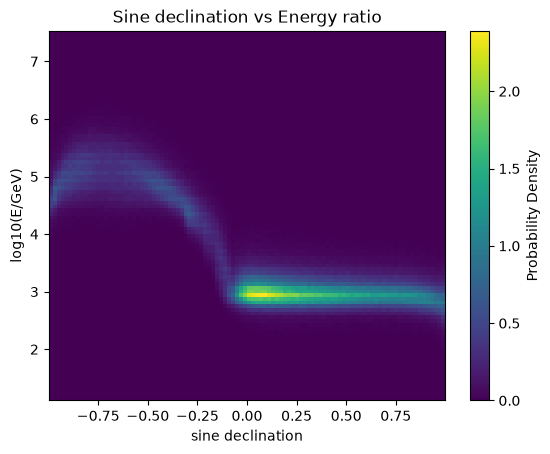

In [91]:
sin_dec = np.sin(df["Dec[deg]"]*(np.pi/180))
E_per_GeV = df["log10(E/GeV)"]
plt.hist2d(sin_dec, E_per_GeV ,bins=100, density=True)
plt.xlabel("sine declination")
plt.ylabel("log10(E/GeV)")
plt.title("Sine declination vs Energy ratio")
plt.colorbar(label="Probability Density")
plt.show()

In [92]:
def solve_theta(latitude, tolerance, max_steps = 30):
    error_flag = np.abs(np.abs(latitude) - np.pi/2) <= tolerance
    theta = latitude.copy()
    theta[error_flag] = 0
    theta_func = lambda x : x - ((2*x + np.sin(2*x) - np.pi*np.sin(latitude))/(2 + 2*np.cos(2*x)))

    diff = np.abs(theta_func(theta) - theta)

    steps = 0
    while((np.max(diff[~error_flag]) >= tolerance) and (steps < max_steps)):
        theta_new = theta_func(theta)
        diff = np.abs(theta_new - theta)
        theta = theta_new
        steps += 1

    theta[error_flag] = latitude[error_flag]
    return theta

    
def mollewide_proj(longitude, latitude, R, central_meredian = 180):
    delta_longitude = (longitude - central_meredian + 180) % 360 - 180
    latitude = latitude * np.pi/180
    delta_longitude *= np.pi/180
    theta_solution = solve_theta(latitude, tolerance = 1e-8)   
    x = (R*2*np.sqrt(2)/np.pi)*delta_longitude*np.cos(theta_solution)
    y = R*np.sqrt(2)*np.sin(theta_solution)
    return x,y

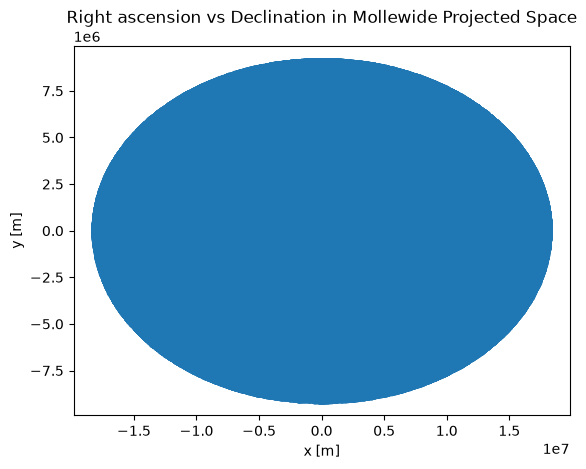

In [95]:
x,y = mollewide_proj(df["RA[deg]"], df["Dec[deg]"], R=6371000)
plt.scatter(x,y)
plt.xlabel("x [m]")
plt.ylabel("y [m]")
plt.title("Right ascension vs Declination in Mollewide Projected Space")
plt.show()